In [19]:
# !pip install folium osmnx geopandas pandas shapely

import folium
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from datetime import datetime

In [20]:
### CONSTS ###
TRAFFIC_DIR = "../data/traffic"

LAT = 48.14553552490184
LNG = 17.114780288953938
MAP_ZOOM = 14
MAP_WIDTH = 2304
MAP_HEIGHT = 2304

START_TIME = datetime(2025, 1, 31, 2, 0)
END_TIME = datetime(2025, 1, 31, 20, 0)

In [21]:
from city_graph import build_road_graph, visualize_graph

G_major, nodes_major, edges_major = build_road_graph("Bratislava, Slovakia")

m = visualize_graph(nodes_major, edges_major)
m

Loaded 5 traffic images in selected interval.



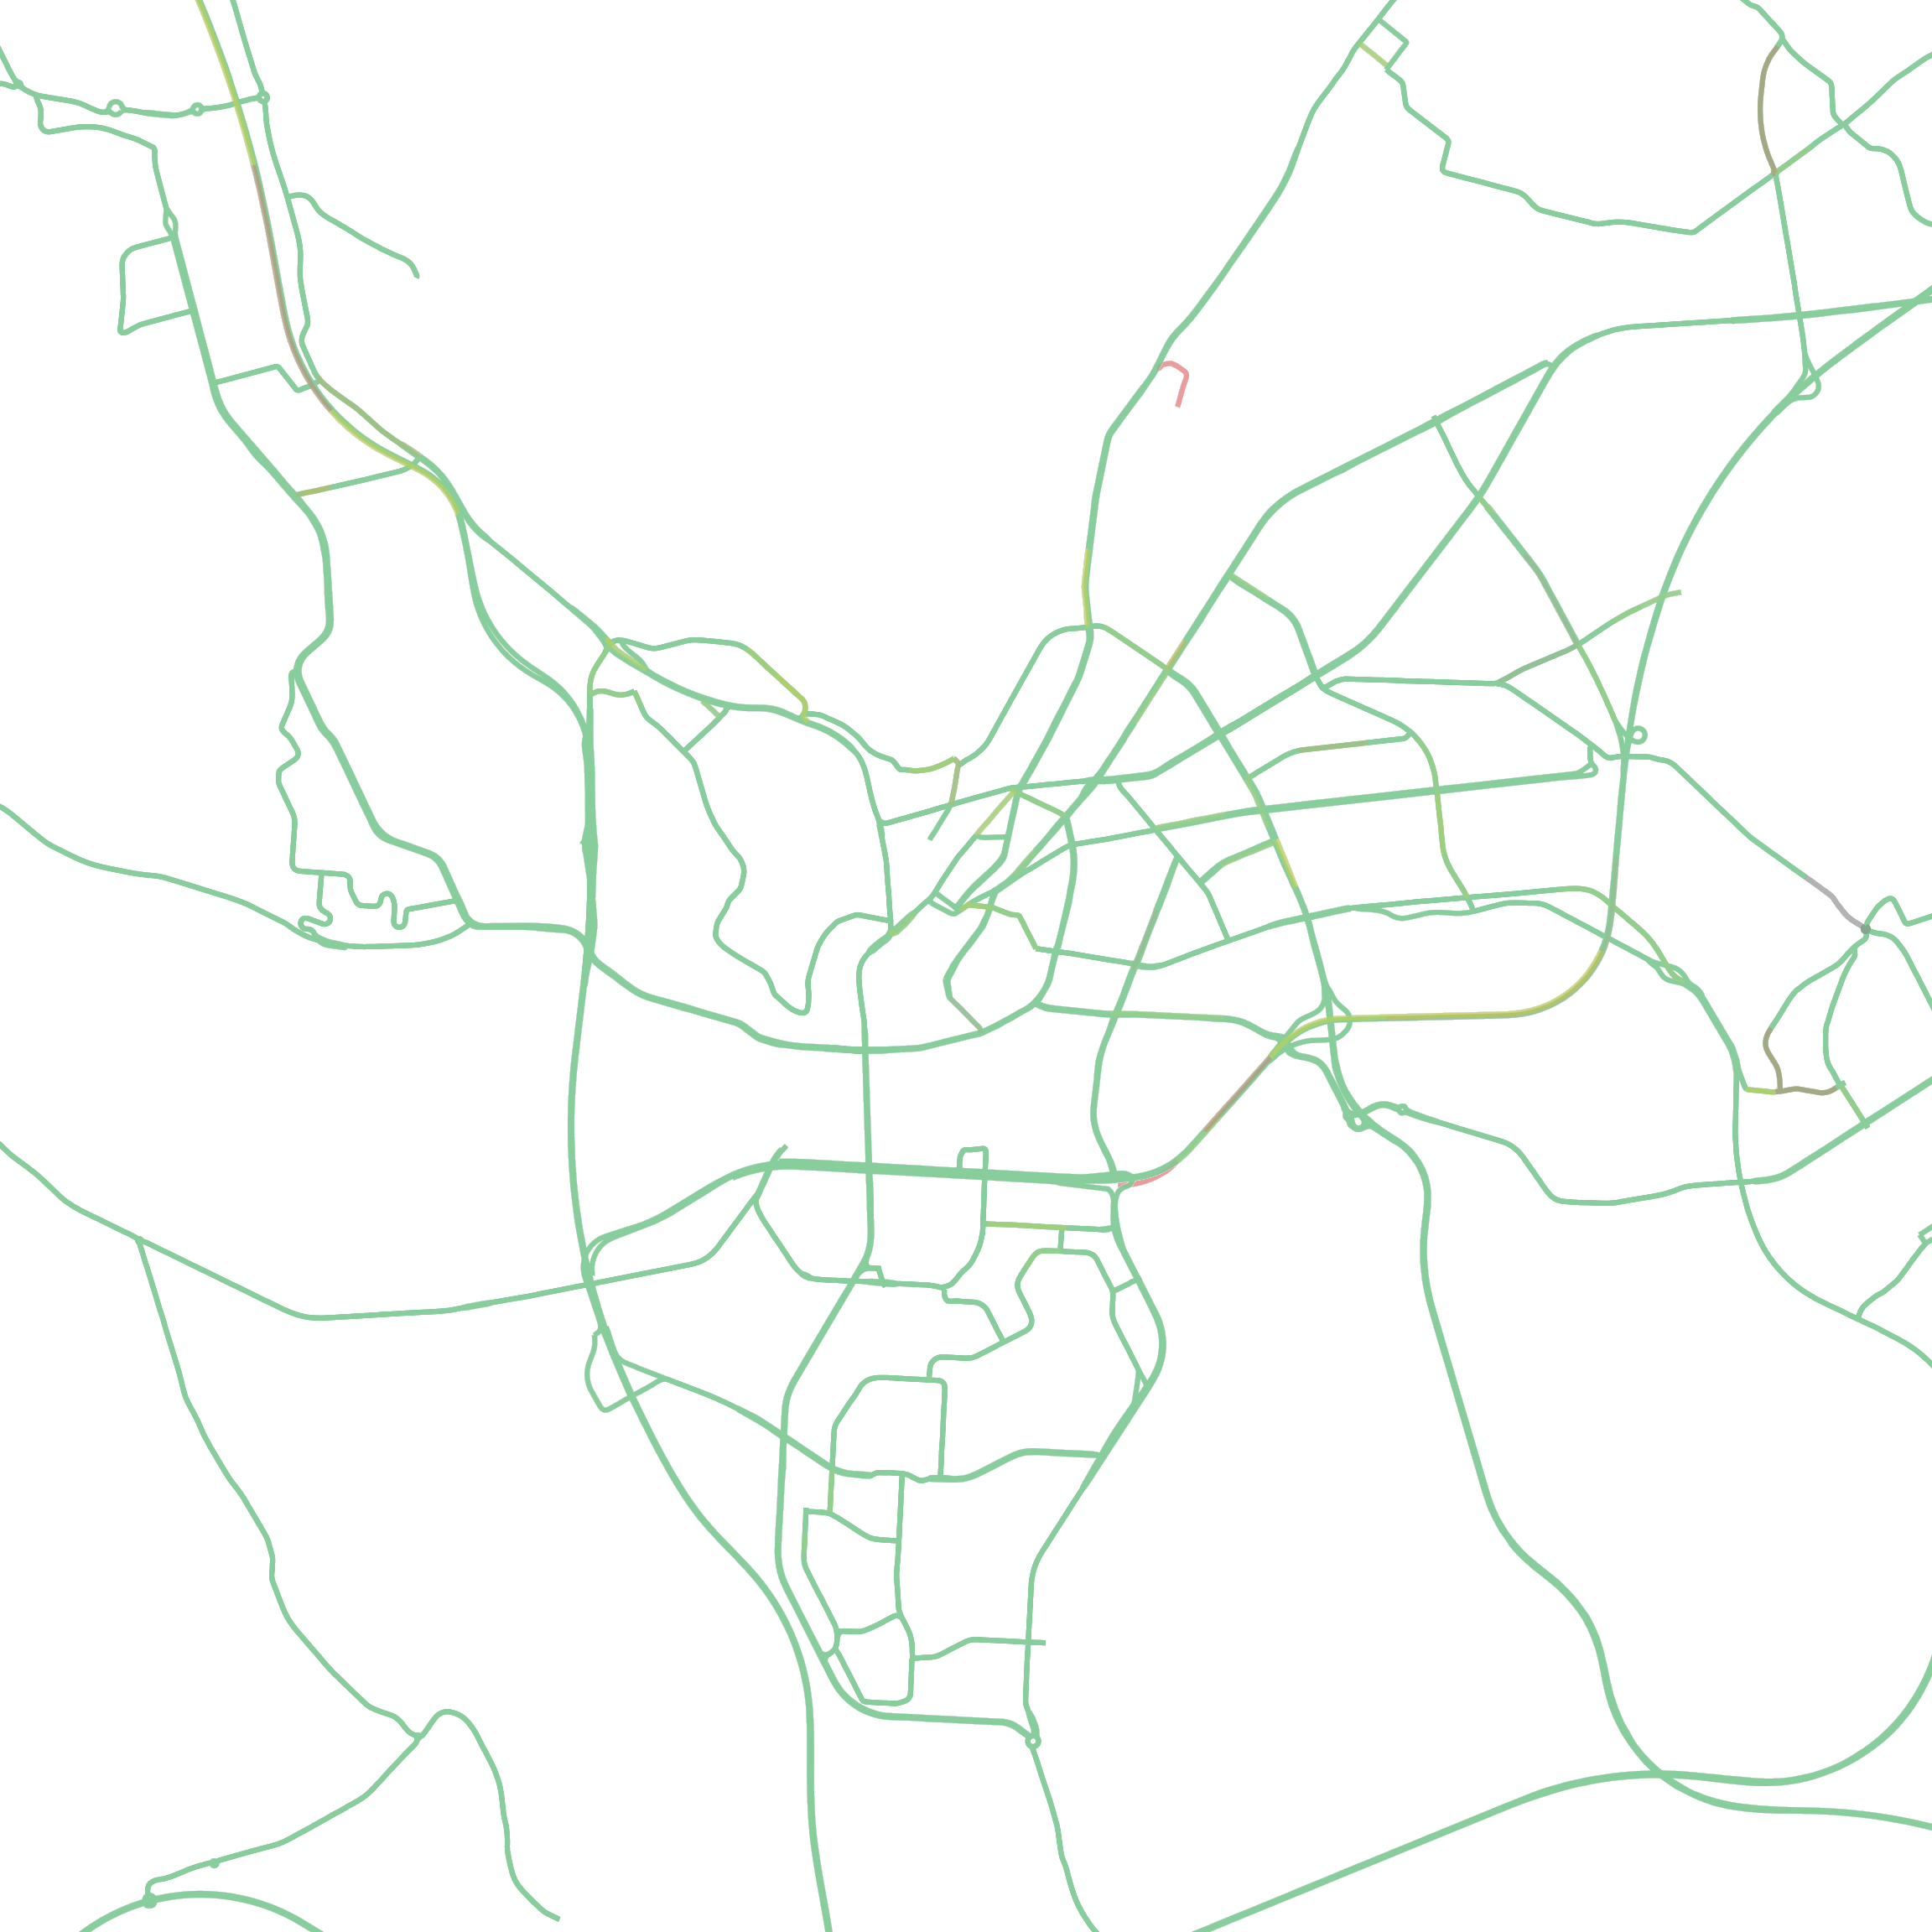

In [22]:
from traffic_data import build_traffic_raster, visualize_traffic_raster

aggregated_image = build_traffic_raster(
    folder=TRAFFIC_DIR, start_time=START_TIME, end_time=END_TIME
)

traffic_map = visualize_traffic_raster(
    aggregated_image=aggregated_image,
    center_lat=48.14553552490184,
    center_lng=17.114780288953938,
    zoom=14,
    width=2304,
    height=2304,
)
traffic_map

In [23]:
from traffic_graph import add_congestion_to_graph, visualize_weighted_graph


G_weighted = add_congestion_to_graph(
    graph=G_major,
    raster_image=aggregated_image,
    center_lat=LAT,
    center_lng=LNG,
    zoom=MAP_ZOOM,
    width=MAP_WIDTH,
    height=MAP_HEIGHT,
)
print(G_weighted)

map_congestion = visualize_weighted_graph(G_weighted, center_lat=LAT, center_lng=LNG)
map_congestion

MultiDiGraph with 1961 nodes and 2935 edges
